Train X,y: (58624, 12, 128) (58624, 128)
Test  X,y: (10776, 12, 128) (10776, 128)
[Spoof ratio per window]
 Train mean=0.0113 min=0.0000 max=0.0859
 Test  mean=0.0863  min=0.0000  max=0.3125


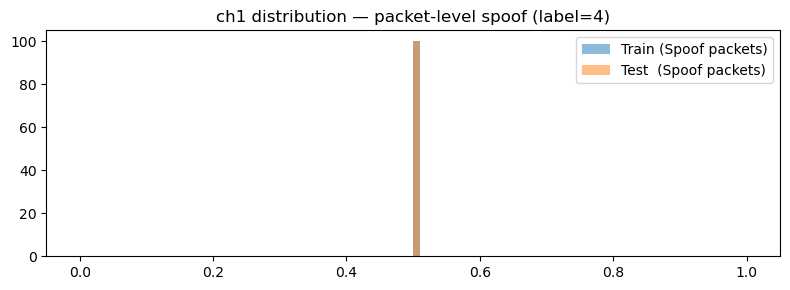

[ch1] Train mean=0.5000 std=0.0000 n=85166
[ch1] Test  mean=0.5000 std=0.0000 n=119013
------------------------------------------------------------


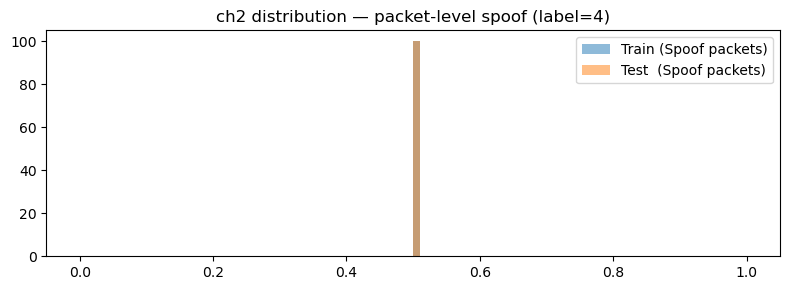

[ch2] Train mean=0.5000 std=0.0000 n=85166
[ch2] Test  mean=0.5000 std=0.0000 n=119013
------------------------------------------------------------


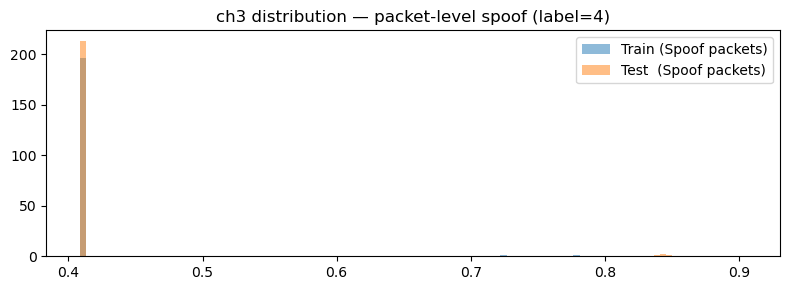

[ch3] Train mean=0.4158 std=0.0493 n=85166
[ch3] Test  mean=0.4215 std=0.0744 n=119013
------------------------------------------------------------


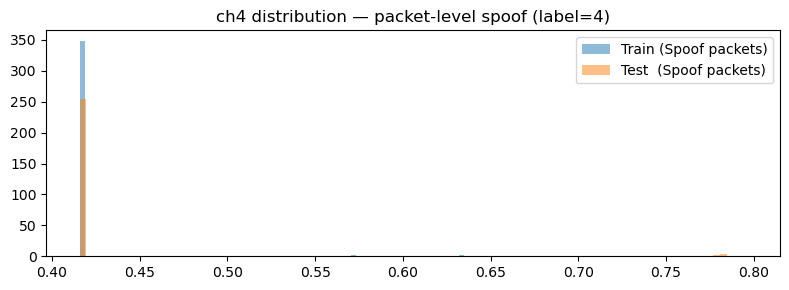

[ch4] Train mean=0.4201 std=0.0295 n=85166
[ch4] Test  mean=0.4268 std=0.0627 n=119013
------------------------------------------------------------


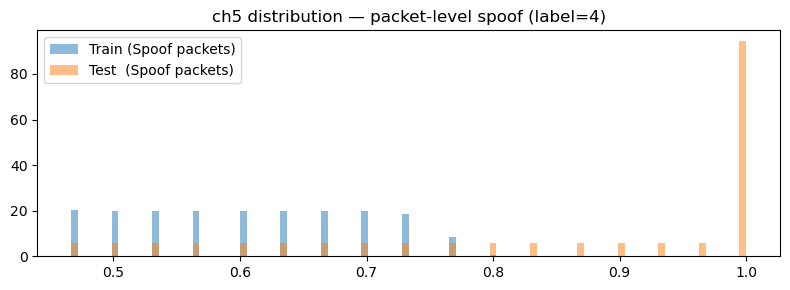

[ch5] Train mean=0.6077 std=0.0928 n=85166
[ch5] Test  mean=0.8591 std=0.1786 n=119013
------------------------------------------------------------


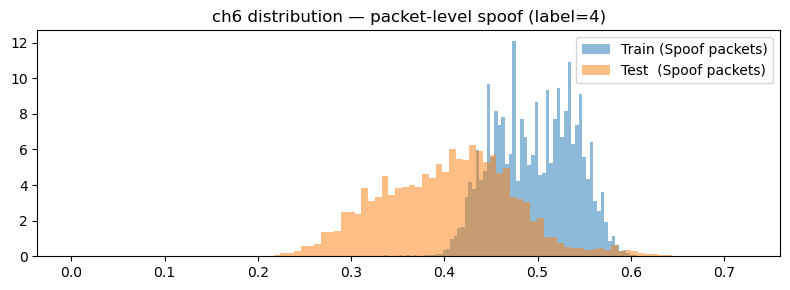

[ch6] Train mean=0.4963 std=0.0437 n=85166
[ch6] Test  mean=0.4039 std=0.0711 n=119013
------------------------------------------------------------


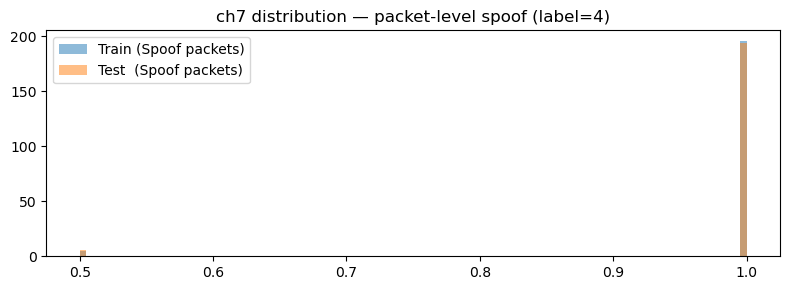

[ch7] Train mean=0.9889 std=0.0738 n=85166
[ch7] Test  mean=0.9849 std=0.0856 n=119013
------------------------------------------------------------


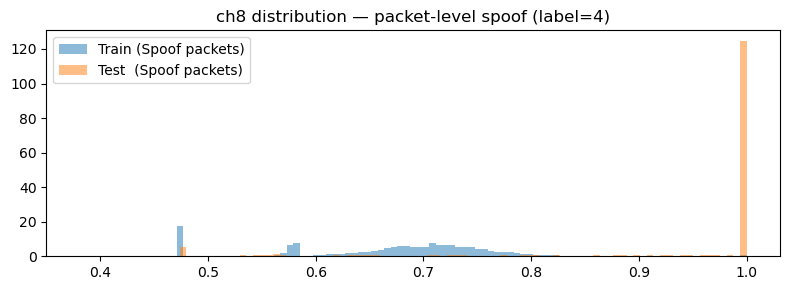

[ch8] Train mean=0.6715 std=0.0920 n=85166
[ch8] Test  mean=0.9368 std=0.1405 n=119013
------------------------------------------------------------


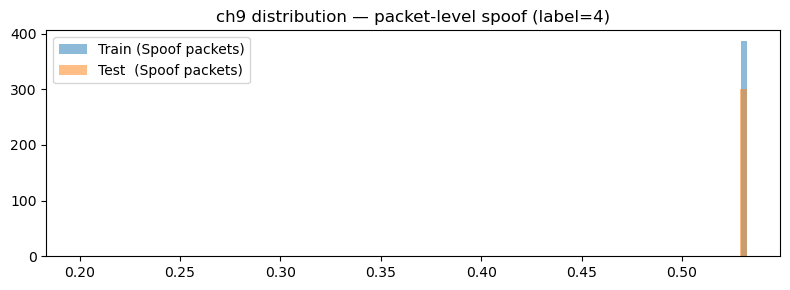

[ch9] Train mean=0.5320 std=0.0047 n=85166
[ch9] Test  mean=0.5321 std=0.0030 n=119013
------------------------------------------------------------


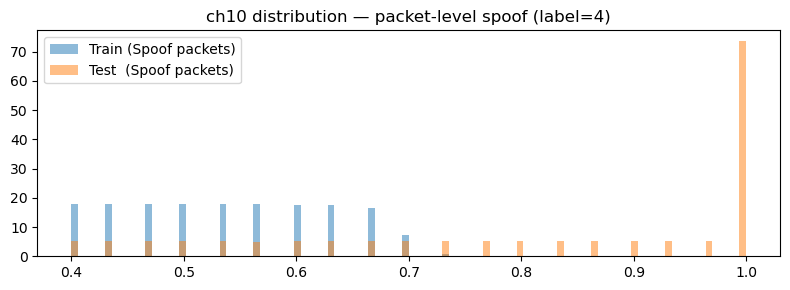

[ch10] Train mean=0.5411 std=0.0931 n=85166
[ch10] Test  mean=0.8231 std=0.2037 n=119013
------------------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dataset_npz_path = "C:/Users/user/Desktop/IDS_masters/dataset/carchallenge_robust_0305.npz"
test_path = "C:/Users/user/Desktop/IDS_masters/dataset/carhacking_robust_0305.npz"

ATTACK_LABEL = 4
CHANNELS = [0,1,2,3,4,5,6,7,8,9,10]
CH_NAMES = ["ch1", "ch2", "ch3","ch4","ch5", "ch6", "ch7","ch8","ch9","ch10"]

# ----------------------------
# Load
# ----------------------------
train_data = np.load(dataset_npz_path)
test_data  = np.load(test_path)

X_train, y_train = train_data["X"], train_data["y"]
X_test,  y_test  = test_data["X"],  test_data["y"]

# ----------------------------
# Fix shapes to (N, C, L) = (N, 12, 128)
# ----------------------------
assert X_train.ndim == 3 and X_test.ndim == 3
assert y_train.ndim == 2 and y_test.ndim == 2

# Train은 (N,12,128)라고 했으니 체크
assert X_train.shape[1] == 12 and X_train.shape[2] == 128, f"Train X shape expected (N,12,128), got {X_train.shape}"
assert y_train.shape[1] == 128, f"Train y shape expected (N,128), got {y_train.shape}"

# Test는 (N,128,12)면 transpose
if X_test.shape[1] == 128 and X_test.shape[2] == 12:
    X_test = np.transpose(X_test, (0, 2, 1))  # -> (N,12,128)

# 이제 test도 (N,12,128)인지 확인
assert X_test.shape[1] == 12 and X_test.shape[2] == 128, f"Test X shape expected (N,12,128), got {X_test.shape}"
assert y_test.shape[1] == 128, f"Test y shape expected (N,128), got {y_test.shape}"

print("Train X,y:", X_train.shape, y_train.shape)
print("Test  X,y:", X_test.shape,  y_test.shape)

# ----------------------------
# (Optional) Spoof ratio per window
# ----------------------------
spoof_ratio_train = (y_train == ATTACK_LABEL).mean(axis=1)
spoof_ratio_test  = (y_test  == ATTACK_LABEL).mean(axis=1)
print("[Spoof ratio per window]")
print(f" Train mean={spoof_ratio_train.mean():.4f} min={spoof_ratio_train.min():.4f} max={spoof_ratio_train.max():.4f}")
print(f" Test  mean={spoof_ratio_test.mean():.4f}  min={spoof_ratio_test.min():.4f}  max={spoof_ratio_test.max():.4f}")

# ----------------------------
# Packet-level (time-step) extraction + plot
# ----------------------------
pos_train = (y_train == ATTACK_LABEL)  # (N,128)
pos_test  = (y_test  == ATTACK_LABEL)

for ch_idx, ch_name in zip(CHANNELS, CH_NAMES):
    train_vals = X_train[:, ch_idx, :][pos_train]  # spoof 패킷 위치만
    test_vals  = X_test[:,  ch_idx, :][pos_test]

    if train_vals.size == 0 or test_vals.size == 0:
        print(f"[{ch_name}] No spoof packets found. train={train_vals.size}, test={test_vals.size}")
        continue

    plt.figure(figsize=(8, 3))
    plt.hist(train_vals, bins=100, alpha=0.5, density=True, label="Train (Spoof packets)")
    plt.hist(test_vals,  bins=100, alpha=0.5, density=True, label="Test  (Spoof packets)")
    plt.title(f"{ch_name} distribution — packet-level spoof (label={ATTACK_LABEL})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"dist_{ch_name}_spoof_packets.png")
    plt.show()

    print(f"[{ch_name}] Train mean={train_vals.mean():.4f} std={train_vals.std():.4f} n={train_vals.size}")
    print(f"[{ch_name}] Test  mean={test_vals.mean():.4f} std={test_vals.std():.4f} n={test_vals.size}")
    print("-" * 60)


